<div style="display: flex; gap: 10px;">
  <img src="../images/HOOPS_AI.jpg" style="width: 20%;">

# Predicting Missing Metadata with the HOOPS AI Context Layer

This tutorial combines **CAD similarity search** with the **Context Layer** to predict
missing PLM metadata (`Material`, `Process`, `Cost`) for a query part by looking at
the metadata of its closest neighbors.

**Prerequisites — indexed database:** This notebook loads a pre-built FAISS index
produced by
[`demo_HOOPS_Embeddings_indexing.ipynb`](./demo_HOOPS_Embeddings_indexing.ipynb).
Run that notebook first if you haven't already.

**Pre-trained vs. custom model:** The index was built with the **pre-trained
`HOOPSEmbeddings` model** bundled in the HOOPS AI release. The library also lets you
train a model on your own CAD dataset, which typically gives better retrieval accuracy
for your specific domain — see
[`3e_workflow_for_HOOPS_EMBEDDINGS_fabwave.ipynb`](../notebooks/3e_workflow_for_HOOPS_EMBEDDINGS_fabwave.ipynb)
for the training workflow.

**API reference:** [hoops_ai.ml.context_layer](https://docs.techsoft3d.com/hoops/ai/api_ref/hoops_ai.ml.context_layer.html)

## Dataset

This notebook uses the **TMCAD** dataset (Truly Mechanical CAD Dataset):

> Zou, Q., & Zhu, L. (2025). Bringing attention to CAD: Boundary representation learning via transformer. *Computer-Aided Design*, 103940.

- TMCAD v2 (recommended): <https://pan.zju.edu.cn/share/218d10a88e8c18f5b96e94a7e0>
- Documentation: <https://github.com/Qiang-Zou/BRT/blob/main/DATASET.md>

~10,000 STEP models across 10 mechanical part categories. Released under **GPL-3.0**.

In [1]:
import hoops_ai
import os
import sys

license_key = os.environ.get("HOOPS_AI_LICENSE")
if not license_key:
    sys.exit("HOOPS_AI_LICENSE environment variable is required.")

hoops_ai.set_license(license_key, validate=True)

------------------------------------------------------------
HOOPS AI
------------------------------------------------------------
  Platform      : Windows 11
  Architecture  : AMD64
  Python        : 3.12.10
------------------------------------------------------------
  Core          : hoops-ai             1.1.0  (build: ed23c844 2026-06-12T14:14:13Z)
  CAD Access    : hoops-exchange       26.2.0  (build: 1e11169 2026-06-12T10:38:16Z)
  Conversion    : hoops-converter      26.1.1  (build: 00dc9f6 2026-06-12T10:22:46Z)
  Insights      : hoops-web-viewer     26.1.1  (build: d30058f 2026-06-12T10:22:25Z)
------------------------------------------------------------
[OK] HOOPS AI License: Valid


# Configure

In [2]:
from hoops_ai.ml.embeddings import HOOPSEmbeddings, Embedding, EmbeddingBatch
import pathlib

packages_dir = pathlib.Path.cwd().parent.joinpath("packages")
pretrained_model = packages_dir.joinpath("trained_ml_models", "ts3d_2M_hoops_embeddings_SIGNAL-preview.ckpt")
demo_cad_files_folder = packages_dir.joinpath("vectorstores","tmcad","queries_for_demo")
indexed_database = packages_dir.joinpath("vectorstores","tmcad","TMCAD_SIGNAL.faiss")

# Register your custom model (trained using EmbeddingFlowModel)
HOOPSEmbeddings.register_model(
    model_name="HOOPS Embeddings SIGNAL preview",
    checkpoint_path=str(pretrained_model)
)

print(HOOPSEmbeddings.list_available_models())

['HOOPS Embeddings SIGNAL preview']


## 1. Set up the CAD similarity search

Register the pre-trained model, load the FAISS index built in
[`demo_HOOPS_Embeddings_indexing.ipynb`](./demo_HOOPS_Embeddings_indexing.ipynb),
and point to a folder of query CAD files. For a step-by-step explanation of each
operation, see the
[CAD search tutorial](../notebooks/5b_cad_search_using_HOOPS_embeddings.ipynb).

In [3]:

embedder = HOOPSEmbeddings(model="HOOPS Embeddings SIGNAL preview")

print(f"Using model: {embedder.model_name} with dimension: {embedder.embedding_dim}")

Successfully loaded model from checkpoint: c:\Users\LuisSalazar.LY-LS-LEGION\Documents\repos\HOOPS-AI-tutorials\packages\trained_ml_models\ts3d_2M_hoops_embeddings_SIGNAL-preview.ckpt
Using model: HOOPS Embeddings SIGNAL preview with dimension: 2048


c:\Users\LuisSalazar.LY-LS-LEGION\Documents\hoops-ai-packages-test\.venv\Lib\site-packages\pytorch_lightning\utilities\parsing.py:136: pytorch_lightning save_hyperparameters: frame introspection failed. Nuitka-compiled frames have empty locals, which breaks PL's collect_init_args. Pass an explicit dict to save_hyperparameters() for correct hparams under Nuitka.


In [4]:
from hoops_ai.storage import CADFileRetriever, LocalStorageProvider

retriever = CADFileRetriever(storage_provider=LocalStorageProvider(directory_path=demo_cad_files_folder), formats=[".stp", ".step", ".iges", ".igs"])
            
# Get files using the library's retriever
cad_files = retriever.get_file_list()
print(len(cad_files), "files found." )


20 files found.


In [5]:
from hoops_ai.ml import CADSearch

loaded_searcher = CADSearch(shape_model=embedder)

embeddingBatch = loaded_searcher.load_shape_index(path=str(indexed_database))

print(f"Loaded {len(embeddingBatch.ids)} part embeddings (dim={embeddingBatch.values.shape[1]}).")


Loaded 39736 part embeddings (dim=2048).


In [6]:
from hoops_ai.insights import DatasetViewer

ds_viewer = DatasetViewer([], [], [], reference_dir=packages_dir.joinpath("vectorstores","tmcad","images_tmcad"))

## 2. The Context Layer — predicting missing metadata

Once we know which parts look like the query, the **Context Layer** fills in missing
PLM fields by aggregating values from the neighbors. Three objects from
[`hoops_ai.ml.context_layer`](https://docs.techsoft3d.com/hoops/ai/api_ref/hoops_ai.ml.context_layer.html)
are involved:

| Object | Role |
|---|---|
| `ContextProvider` | Supplies metadata for a list of part ids. Implement `get_contexts(ids)` to read from your PLM, SQL store, or JSON file. |
| `AggregationRule` | Defines how neighbour values are combined. Three built-in rules: `CategoricalRule` (softmax-weighted vote), `NumericWeightedRule` (weighted mean with optional log-scale and auto relevance weighting), `NearestNeighborRule` (borrow the top hit's value when similarity clears a threshold). |
| `ContextPredictor` | Orchestrates the prediction. `predictor.infer(hits, keys=[...])` resolves categorical keys first, forwards them into numeric rules, and returns a `dict[str, ContextPrediction]` with `value`, `confidence`, and `status` (`ready_to_propose`, `needs_review`, or `insufficient_evidence`). |

## 3. The example PLM (mock — not part of the library)

`database.py` provides `OnDemandContextProvider`: a `ContextProvider` subclass that
synthesizes deterministic records from each file's stem so the notebook runs without
a real PLM.

It deliberately leaves some records incomplete to mimic reality:
- **The top hit is always empty** — the predictor must aggregate from the rest.
- The other records follow a **50 / 30 / 20 mix**: ~50 % full, ~30 % text-only (`Material` + `Process`), ~20 % empty.
- **~60 % of queries land in consensus mode**, where one `(Material, Process)` pair dominates — enough for the predictor to reach `ready_to_propose`. The other ~40 % stay varied so you can also observe `needs_review` and `insufficient_evidence` outputs.

> In your own project, replace `OnDemandContextProvider` with a `ContextProvider` subclass backed by your actual PLM or metadata store.

In [7]:
import importlib, database
importlib.reload(database)
from database import OnDemandContextProvider

from hoops_ai.ml.context_layer import (
    ContextPredictor, CategoricalRule, NumericWeightedRule, NearestNeighborRule,
)
from hoops_ai.insights import predictions_table, hits_table

# search_by_shape returns a list-of-lists (one neighbour list per query);
# we always work on the first query.
part_index = 0

# --- Example-only mock. Swap for your own ContextProvider in production. ---
context_provider = OnDemandContextProvider()

# --- Library: rule for the numeric Cost key ---
# - log_scale: average in log-space (geometric mean), good for prices
# - auto_relevance_weight: sharpen weights using textual-tag agreement
# - nearest_neighbor_threshold: short-circuit to the best neighbour
#   when its weighter-adjusted score clears the gate
# - score_temperature: softmax sharpness for the fallback weighted mean
cost_rule = NumericWeightedRule(
    log_scale=True,
    auto_relevance_weight=True,
    nearest_neighbor_threshold=0.98,
    score_temperature=12.0,
)

# --- Library: the predictor ---
# Default categorical rule for any key not listed in per_key_rules.
# We override two keys:
#   - InternalFeatures: shape-intrinsic count -> NearestNeighborRule
#     (borrow the top hit's value only when similarity >= 0.99)
#   - Cost: the numeric rule above
predictor = ContextPredictor(
    context_provider,
    default_categorical_rule=CategoricalRule(temperature=12.0, min_margin=0.05),
    per_key_rules={
        "InternalFeatures": NearestNeighborRule(threshold=0.99),
        "Cost": cost_rule,
    },
)


## 4. Run the predictor on a few queries

For each query we:

1. Run a shape search with `loaded_searcher.search_by_shape(query, top_k=...)`.
2. Print the neighbors and their raw metadata with `hits_table`.
3. Call `predictor.infer(hits, keys=[...])` and render the result with `predictions_table`.

The `injected_context` column in `predictions_table` shows which categorical values
were forwarded into numeric rules. Forwarding only happens when a categorical
prediction reaches `ready_to_propose` — predictions that stay at `needs_review` are
**not** injected and the Cost rule operates without that context. Example 1 includes
a follow-up cell that demonstrates the effect of relaxing the `status_policy`.

### Example 1 — strong consensus

The neighbour set agrees on a single `(Material, Process)` pair. We
expect both categorical keys to reach `ready_to_propose` and `Cost` to
settle at a high confidence (status `needs_review`, because monetary
values use the strictest policy).


Querying with: c:\Users\LuisSalazar.LY-LS-LEGION\Documents\repos\HOOPS-AI-tutorials\packages\vectorstores\tmcad\queries_for_demo\1.stp
Reusing 15 existing PNGs and generating 0 PNGs using persistent process pool...


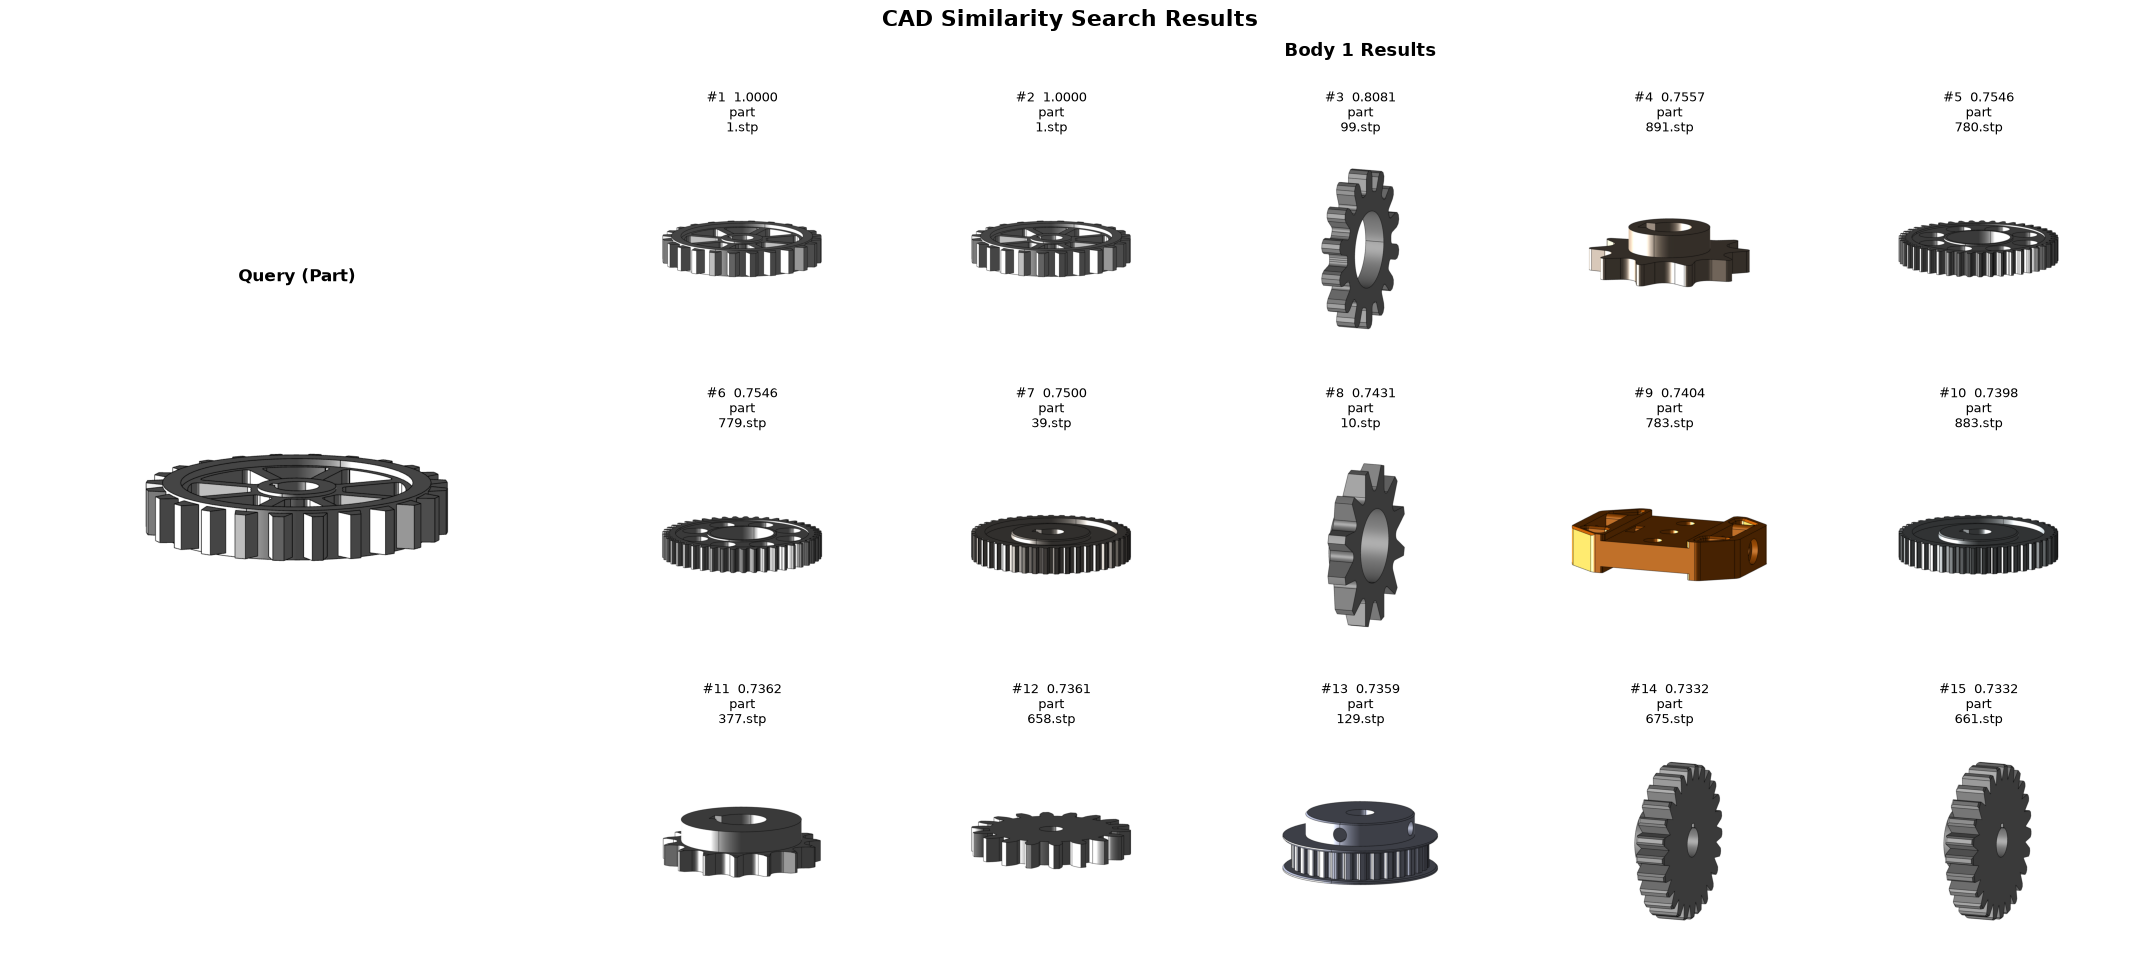

In [8]:
query = str(cad_files[1])
print(f"Querying with: {query}")
hits = loaded_searcher.search_by_shape(query, top_k=15, filters={"kind": "part"})

ds_viewer.show_search_results(hits, query_file=query, grid_cols=5)

In [9]:
# Get the engineering context data attached to those parts —
# score in column 1, then the resolved PLM values.
metadata_by_id = context_provider.get_contexts([h.id for h in hits[part_index]])
hits_table(hits[part_index], metadata_by_id, keys=["Material", "Process", "InternalFeatures", "Cost"])


,id,score,Material,Process,InternalFeatures,Cost
rank,,,,,,
1,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\queries_for_demo\1.stp,1.00,—,—,—,—
2,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\1.stp,1.00,—,—,—,—
3,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\99.stp,0.81,Stainless Steel,Turning,11,126.890000
4,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\891.stp,0.76,Stainless Steel,Turning,13,150.810000
5,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\780.stp,0.75,Stainless Steel,Turning,8,110.070000
6,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\779.stp,0.75,Aluminum,CNC Milling,—,—
7,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\39.stp,0.75,Stainless Steel,Turning,6,94.530000
8,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\10.stp,0.74,Stainless Steel,Turning,11,132.420000
9,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\pulley\783.stp,0.74,Stainless Steel,Turning,16,194.480000


In [10]:
predictions = predictor.infer(
    hits[part_index],
    keys=["Material", "Process", "Cost"],
    query_context = {"InternalFeatures": 9},
)
predictions_table(predictions)

,value,confidence,status,coverage,context
key,,,,,
Material,Stainless Steel,76%,ready_to_propose,11/15,
Process,Turning,76%,ready_to_propose,11/15,
Cost,129.806007,81%,needs_review,8/15,"InternalFeatures=9, Material=Stainless Steel, Process=Turning"


In [11]:
true_cost = database.compute_true_cost_from_equation(material=predictions['Material'].value, process=predictions['Process'].value, internal_features=9)
print(f"Predicted Cost: {predictions['Cost'].value:.2f}, True Cost: {true_cost:.2f}")

Predicted Cost: 129.81, True Cost: 114.15


### Example 2 — different query, different consensus

Same predictor, different query. The consensus pair changes — confirming
that the predictor picks it up from the neighbours, not from any
hard-coded prior.


Reusing 15 existing PNGs and generating 0 PNGs using persistent process pool...


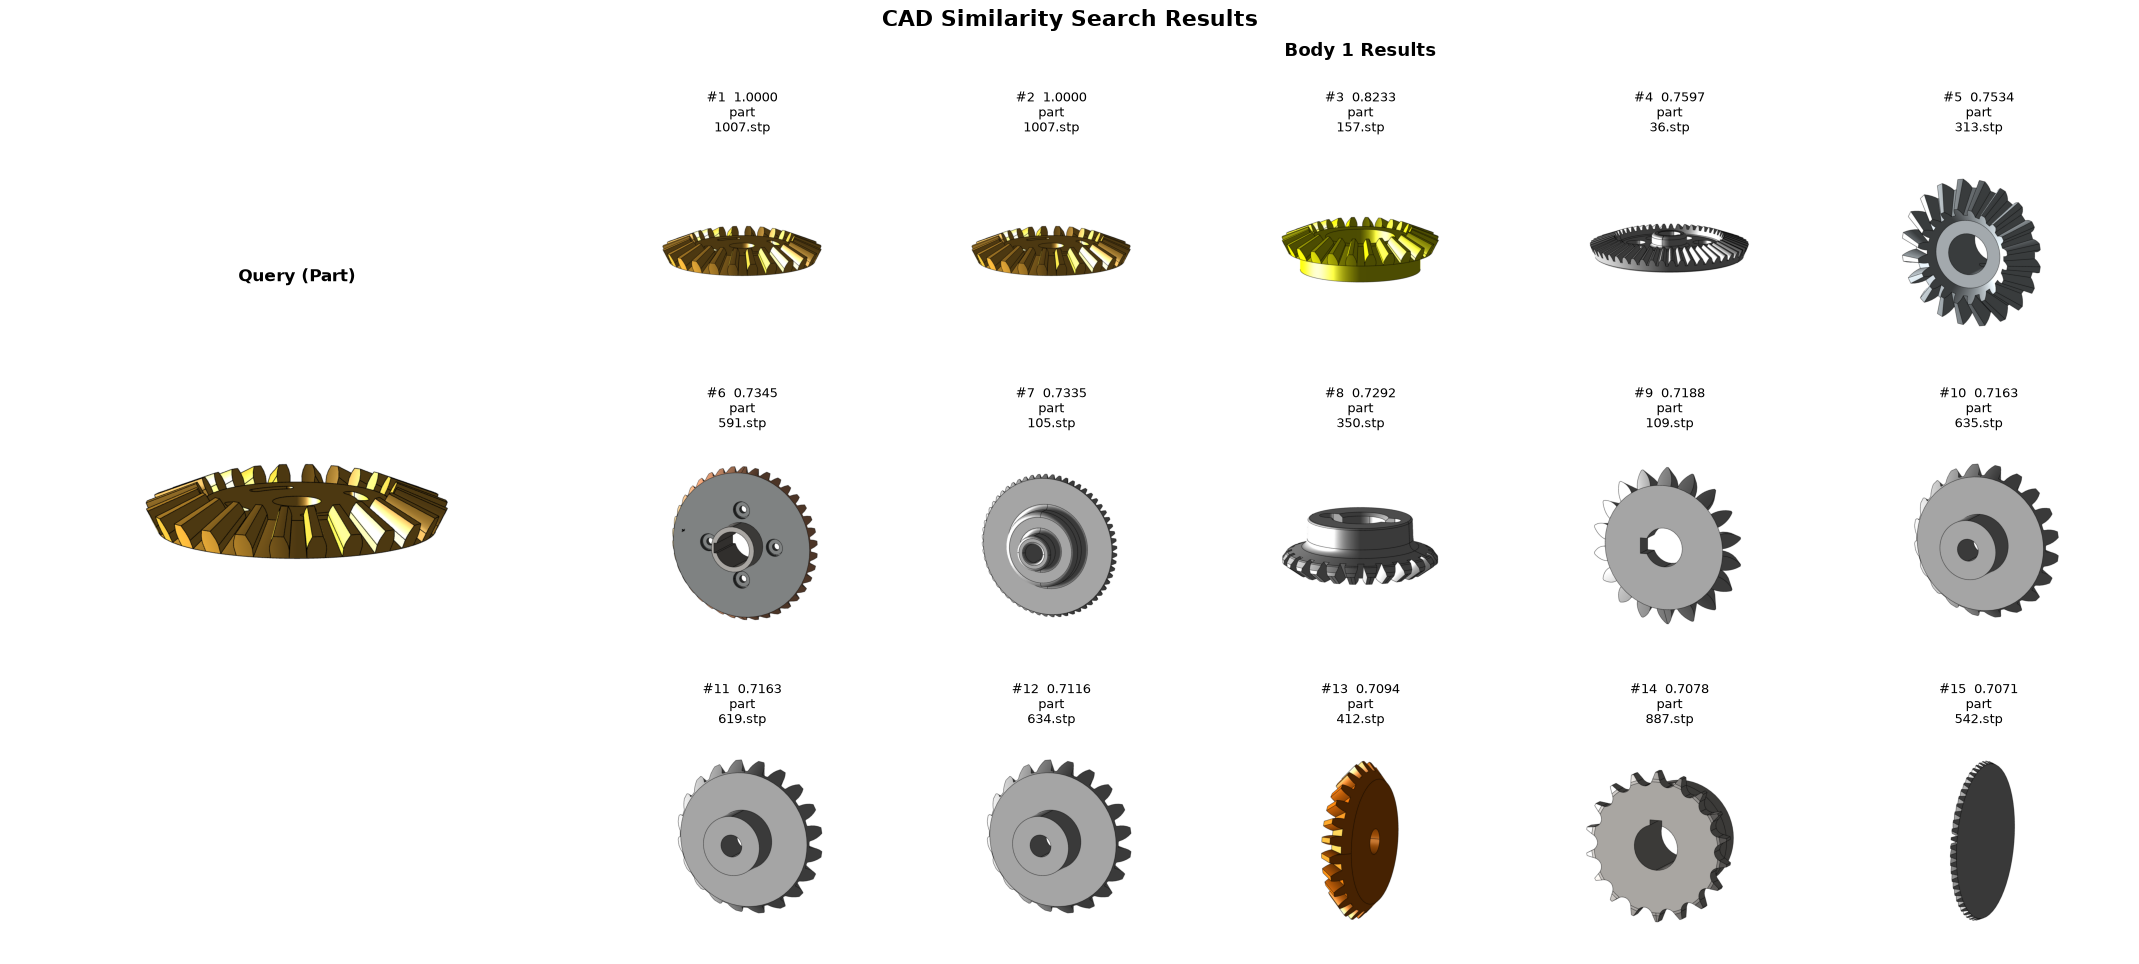

In [12]:
query = str(cad_files[3])
hits = loaded_searcher.search_by_shape(query, top_k=15, filters={"kind": "part"})
ds_viewer.show_search_results(hits, query_file=query, grid_cols=5)

In [13]:
metadata_by_id = context_provider.get_contexts([h.id for h in hits[part_index]])
hits_table(hits[part_index], metadata_by_id, keys=["Material", "Process", "InternalFeatures", "Cost"])


,id,score,Material,Process,InternalFeatures,Cost
rank,,,,,,
1,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\queries_for_demo\1007.stp,1.00,—,—,—,—
2,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\1007.stp,1.00,Stainless Steel,Turning,11,134.580000
3,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\157.stp,0.82,Stainless Steel,Turning,6,86.970000
4,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\36.stp,0.76,Stainless Steel,Turning,17,226.390000
5,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\313.stp,0.75,—,—,—,—
6,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\591.stp,0.73,Stainless Steel,Turning,6,86.140000
7,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\105.stp,0.73,Steel,5-Axis Machining,—,—
8,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\350.stp,0.73,Stainless Steel,Turning,7,95.350000
9,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\gear\109.stp,0.72,—,—,—,—


In [14]:
predictions = predictor.infer(
    hits[part_index],
    keys=["Material", "Process", "InternalFeatures", "Cost"],
)
predictions_table(predictions)


,value,confidence,status,coverage
key,,,,
Material,Stainless Steel,97%,needs_review,9/15
Process,Turning,97%,needs_review,9/15
InternalFeatures,11,100%,needs_review,8/15
Cost,87.164339,95%,needs_review,8/15


### Effect of the status policy on Cost

`ContextPredictor.infer()` accepts a `status_policy` dict that gates which predictions
reach `ready_to_propose`. When a categorical prediction is only `needs_review`, the
predictor does **not** forward it as `query_context` to numeric rules (see
[`ContextPredictor.infer` docs](https://docs.techsoft3d.com/hoops/ai/api_ref/hoops_ai.ml.context_layer.html#hoops_ai.ml.context_layer.ContextPredictor.infer)).
That means the `RelevanceWeighter` inside the Cost rule has no Material / Process
signal and the weighted mean averages across all materials and processes.

Relax the gate by passing a `status_policy` dict with lower thresholds. With
Material and Process now `ready_to_propose`, they are injected into the Cost rule's
`query_context` and the `RelevanceWeighter` re-ranks neighbors accordingly.

#### `status_policy` keys

| Key | Type | What it gates |
|-------|------|------|
| `min_observed_hits` | `      int      ` | Minimum number of neighbors that returned a value for the key. Below this, the prediction is `insufficient_evidence` regardless of confidence. |
| `min_observed_score_weight` | `float [0,1]` | Minimum fraction of the **total score mass** that must come from neighbors that actually have data. A value of `0.5` means at least half the weighted evidence pool must be non-empty. |
| `min_top_share` | `float [0,1]` | Minimum weighted vote share the winning category must hold. E.g. `0.2` means the winner must account for at least 20 % of the softmax-weighted votes. |
| `min_margin` | `float [0,1]` | Minimum gap between the winner's share and the runner-up's share. Prevents `ready_to_propose` when two categories are nearly tied. `0.0` disables the consensus guard entirely. |

All four default to library-defined values when `status_policy` is not passed.
Passing an empty dict `{}` uses zero for every threshold (maximally permissive).
The cell below uses a moderately relaxed policy so you can compare the Cost estimate
with and without Material / Process context being injected.

In [15]:
# Relax the status policy so that high-confidence categoricals reach ready_to_propose
# and get forwarded as query_context into the Cost rule.
permissive_policy = {
    "min_observed_hits": 4,
    "min_observed_score_weight": 0.5,
    "min_top_share": 0.2,
    "min_margin": 0.1,
}

predictions_relaxed = predictor.infer(
    hits[part_index],
    keys=["Material", "Process", "Cost", "InternalFeatures"],
    status_policy=permissive_policy,
)
predictions_table(predictions_relaxed)

,value,confidence,status,coverage,context
key,,,,,
Material,Stainless Steel,97%,ready_to_propose,9/15,
Process,Turning,97%,ready_to_propose,9/15,
Cost,134.580000,100%,ready_to_propose,8/15,"Material=Stainless Steel, Process=Turning, InternalFeatures=11"
InternalFeatures,11,100%,ready_to_propose,8/15,


In [16]:
cost_default   = predictions["Cost"].value
cost_relaxed   = predictions_relaxed["Cost"].value

print(f"Cost (needs_review  categoricals, no context injected): {cost_default:.2f}")
print(f"Cost (ready_to_propose categoricals, context injected):  {cost_relaxed:.2f}")

true_cost = database.compute_true_cost_from_equation(material=predictions['Material'].value, process=predictions['Process'].value, internal_features=predictions['InternalFeatures'].value)
print(f"Predicted Cost: {predictions['Cost'].value:.2f}, True Cost: {true_cost:.2f}")

print(f"True Cost (Stainless Steel + Turning + {predictions['InternalFeatures'].value} features):      {true_cost:.2f}")
print()
# The injected_context field shows what the predictor forwarded into the Cost rule.
injected = predictions_relaxed["Cost"].injected_context
print(f"Injected context for Cost: {injected}")

Cost (needs_review  categoricals, no context injected): 87.16
Cost (ready_to_propose categoricals, context injected):  134.58
Predicted Cost: 87.16, True Cost: 134.85
True Cost (Stainless Steel + Turning + 11 features):      134.85

Injected context for Cost: {'Material': 'Stainless Steel', 'Process': 'Turning', 'InternalFeatures': 11}


### Example 3 — sparse and divided neighbours

This query falls outside consensus mode: half the neighbours are blank,
the rest disagree. The predictor downgrades to `needs_review` /
`insufficient_evidence` instead of overstating confidence — exactly the
behaviour you want when the data isn't there to support a READY
proposal.


Reusing 15 existing PNGs and generating 0 PNGs using persistent process pool...


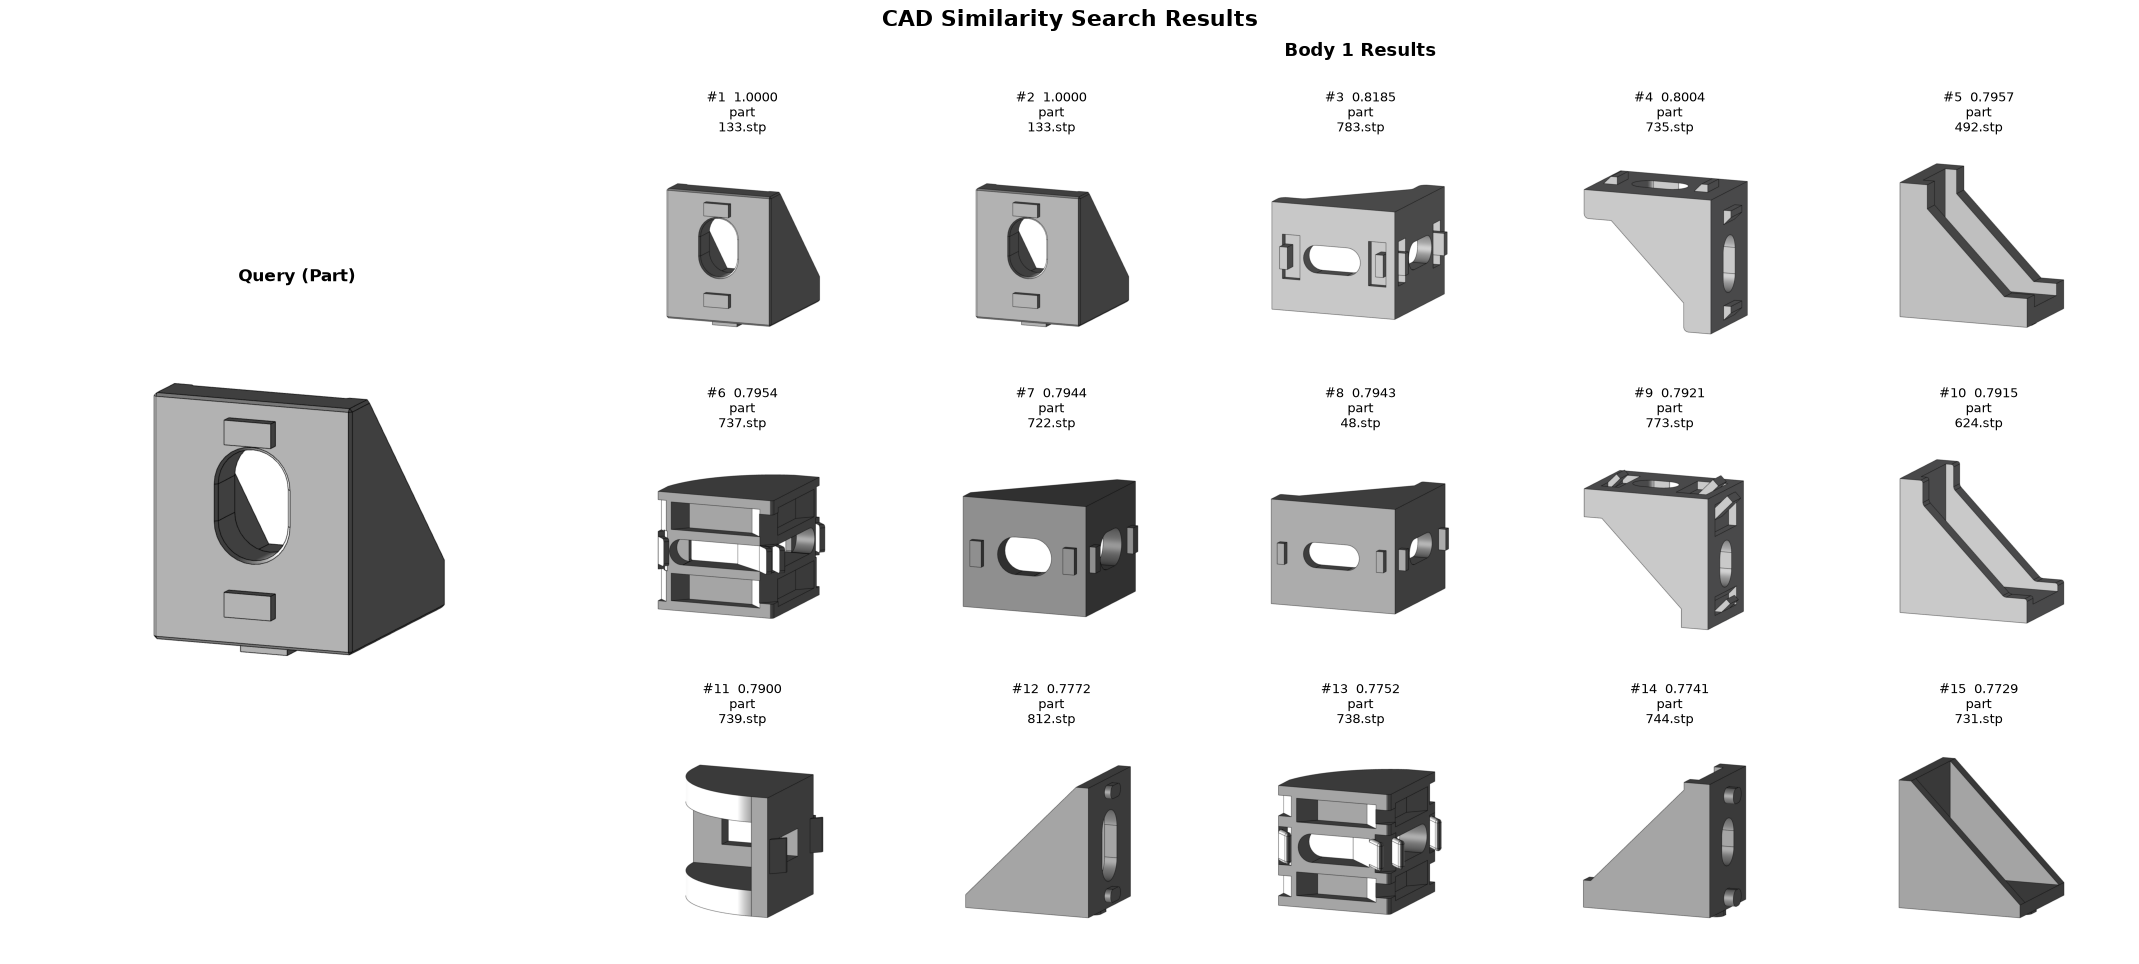

In [17]:
query = str(cad_files[4])
hits = loaded_searcher.search_by_shape(query, top_k=15, filters={"kind": "part"})

ds_viewer.show_search_results(hits, query_file=query, grid_cols=5)

In [18]:
metadata_by_id = context_provider.get_contexts([h.id for h in hits[part_index]])
hits_table(hits[part_index], metadata_by_id, keys=["Material", "Process", "InternalFeatures", "Cost"])

,id,score,Material,Process,InternalFeatures,Cost
rank,,,,,,
1,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\queries_for_demo\133.stp,1.00,—,—,—,—
2,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\133.stp,1.00,Aluminum,Turning,6,41.420000
3,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\783.stp,0.82,Aluminum,Turning,16,92.910000
4,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\735.stp,0.80,Aluminum,Turning,10,58.050000
5,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\492.stp,0.80,Aluminum,Turning,15,82.840000
6,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\737.stp,0.80,Stainless Steel,CNC Milling,—,—
7,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\722.stp,0.79,Aluminum,Turning,8,52.430000
8,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\48.stp,0.79,Aluminum,Turning,14,80.880000
9,C:\Users\LuisSalazar.LY-LS-LEGION\Documents\data\TMCAD_dataset_v2\bracket\773.stp,0.79,Aluminum,Turning,12,67.950000


#### Injecting what you already know — `query_context`

The predictor normally discovers context by aggregating over the neighbors. But you
often already know *something* about the query part — a measurement from a CAD
property, a tag entered by an engineer, a value computed earlier in the pipeline.
That known information should not be re-predicted from neighbors; it should be treated
as ground truth and used to sharpen the predictions for the keys you *don't* know.

`query_context` is the parameter that carries this user-validated knowledge into the
predictor:

```python
predictor.infer(hits, keys=[...], query_context={"InternalFeatures": 9})
```

**What it does internally:**

1. The dict is merged with any `ready_to_propose` categorical predictions before the
   numeric rules run — caller-supplied values always win over auto-forwarded ones.
2. The `RelevanceWeighter` inside `NumericWeightedRule` uses every key in
   `query_context` to re-rank neighbors: a neighbor that shares the same
   `InternalFeatures` count, `Material`, and `Process` as the query will receive a
   higher adjusted score than one that differs on all three.
3. The `nearest_neighbor_threshold` gate in `NumericWeightedRule` operates on the
   *weighter-adjusted* score (not the raw shape score), so injecting `query_context`
   directly raises the bar for a neighbor to qualify as a "near-duplicate" — meaning
   only a neighbor that is both geometrically close **and** metadata-consistent can
   short-circuit to its verbatim Cost value.

**When to use it:**

| Situation | What to inject |
|---|---|
| Part has a known feature count from a CAD property | `{"InternalFeatures": <count>}` |
| Engineer has already validated the material | `{"Material": "Steel"}` |
| Multiple fields already confirmed | Any combination of the above |

In Example 3 below, `InternalFeatures` is set explicitly. Remove it or change the
value to see how the Cost estimate shifts.

In [19]:
predictions = predictor.infer(
    hits[part_index],
    keys=["Material", "Process", "Cost"],
    query_context={"InternalFeatures": 3},
)
predictions_table(predictions)


,value,confidence,status,coverage,context
key,,,,,
Material,Aluminum,88%,ready_to_propose,12/15,
Process,Turning,88%,ready_to_propose,12/15,
Cost,55.696937,75%,needs_review,9/15,"InternalFeatures=3, Material=Aluminum, Process=Turning"


In [20]:
true_cost = database.compute_true_cost_from_equation(material=predictions['Material'].value, process=predictions['Process'].value, internal_features=5)
print(f"Predicted Cost: {predictions['Cost'].value:.2f}, True Cost: {true_cost:.2f}")

Predicted Cost: 55.70, True Cost: 41.60


## Where to go from here

- **Plug in your own data.** Replace `OnDemandContextProvider` with a `ContextProvider`
  subclass backed by your PLM, ERP, or any metadata store. Implement `get_contexts` and
  `list_numeric_keys`.
- **Train your own embedding model** for better search accuracy on your domain — see
  [`3e_workflow_for_HOOPS_EMBEDDINGS_fabwave.ipynb`](../notebooks/3e_workflow_for_HOOPS_EMBEDDINGS_fabwave.ipynb).
- **Tune the policy.** Adjust `temperature`, `min_margin`, and
  `nearest_neighbor_threshold` on the rules to control how aggressively the predictor
  commits to a value.
- **Add a custom rule.** Subclass `AggregationRule` and pass it via `per_key_rules`.
- **Full API reference:** [hoops_ai.ml.context_layer](https://docs.techsoft3d.com/hoops/ai/api_ref/hoops_ai.ml.context_layer.html)